# Soft-Clipped Read Analysis

During initial BAM inspection, multiple alignments contained  soft-clipped sequence segments within their CIGAR strings.

In targeted RNA sequencing, soft clipping may arise from:
- incomplete adapter trimming,
- RNA processing events,
- fusion or rearrangement breakpoints, <- very interesting
- alignment ambiguity,
- sequencing artifacts,
- or structurally complex genomic regions.

This analysis focuses specifically on relatively large soft-clipped segments (>15 bp) to identify recurrent clipping patterns and evaluate whether they likely reflect technical artifacts or biologically meaningful events.

The name of the game here is to identify what soft clipping remnants are categorically technical noise, or real observable biological changes. 

In [1]:
from pathlib import Path
import pysam
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess

bam_dir = Path("../data/bam")
bam_files = sorted(bam_dir.glob("*.bam"))

fig_dir = Path("../results/figures")
table_dir = Path("../results/tables")

bam_files

[PosixPath('../data/bam/sample1.bam'),
 PosixPath('../data/bam/sample2.bam'),
 PosixPath('../data/bam/sample3.bam')]

lets take a look at the soft clips.

In [2]:
softclip_rows = []

for bam_file in bam_files:
    
    sample = bam_file.stem
    bam = pysam.AlignmentFile(bam_file, "rb")
    
    for read in bam.fetch(until_eof=True):
        
        if read.is_unmapped:
            continue
        
        cigar = read.cigartuples
        
        if cigar is None:
            continue
        
        # left soft clip
        if cigar[0][0] == 4:
            left_clip = cigar[0][1]
        else:
            left_clip = 0
        
        # right soft clip
        if cigar[-1][0] == 4:
            right_clip = cigar[-1][1]
        else:
            right_clip = 0
        
        max_clip = max(left_clip, right_clip)
        
        if max_clip >= 15:
            
            softclip_rows.append({
                "sample": sample,
                "chrom": read.reference_name,
                "start": read.reference_start,
                "mapq": read.mapping_quality,
                "cigar": read.cigarstring,
                "left_clip": left_clip,
                "right_clip": right_clip,
                "max_clip": max_clip,
                "read_length": read.query_length
            })

softclip_df = pd.DataFrame(softclip_rows)

softclip_df.head()

[W::hts_idx_load3] The index file is older than the data file: ../data/bam/sample1.bam.bai
[W::hts_idx_load3] The index file is older than the data file: ../data/bam/sample2.bam.bai
[W::hts_idx_load3] The index file is older than the data file: ../data/bam/sample3.bam.bai


,sample,chrom,start,mapq,cigar,left_clip,right_clip,max_clip,read_length
0,sample1,1,3188498,255,17S52M,17,0,17,69
1,sample1,1,3188498,255,19S52M,19,0,19,71
2,sample1,1,8581777,255,52M17S,0,17,17,69
3,sample1,1,8581777,255,52M17S,0,17,17,69
4,sample1,1,8746683,255,18S84M,18,0,18,102


In [3]:
softclip_summary = (
    softclip_df
    .groupby("sample")
    .agg(
        n_softclipped_reads=("cigar", "size"),
        median_softclip=("max_clip", "median"),
        max_softclip=("max_clip", "max"),
        median_mapq=("mapq", "median")
    )
    .reset_index()
)

softclip_summary.to_csv(
    table_dir / "softclip_summary.csv",
    index=False
)

softclip_summary

,sample,n_softclipped_reads,median_softclip,max_softclip,median_mapq
0,sample1,13259,21.0,150,255.0
1,sample2,41892,22.0,151,255.0
2,sample3,21327,22.0,151,255.0


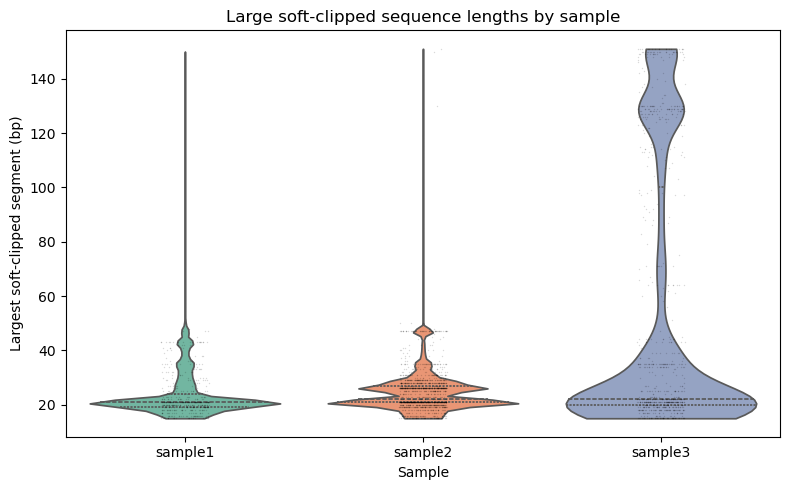

In [4]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=softclip_df,
    x="sample",
    y="max_clip",
    hue="sample",
    inner="quartile",
    palette="Set2",
    legend=False,
    cut=0
)

sns.stripplot(
    data=softclip_df.sample(min(3000, len(softclip_df)), random_state=1),
    x="sample",
    y="max_clip",
    color="black",
    alpha=0.15,
    size=1
)

plt.title("Large soft-clipped sequence lengths by sample")
plt.xlabel("Sample")
plt.ylabel("Largest soft-clipped segment (bp)")

plt.tight_layout()
plt.savefig(fig_dir / "softclip_length_violin_points_by_sample.png", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
softclip_df["bin"] = (softclip_df["start"] // 1000) * 1000

softclip_loci = (
    softclip_df
    .groupby(["sample", "chrom", "bin"])
    .agg(
        n_softclipped_reads=("max_clip", "size"),
        median_softclip=("max_clip", "median"),
        max_softclip=("max_clip", "max")
    )
    .reset_index()
    .sort_values(["sample", "n_softclipped_reads"], ascending=[True, False])
)

softclip_loci["region"] = (
    "chr" + softclip_loci["chrom"].astype(str) + ":" +
    softclip_loci["bin"].astype(str)
)

softclip_loci.to_csv(table_dir / "softclip_loci_summary.csv", index=False)

softclip_loci.head(20)

,sample,chrom,bin,n_softclipped_reads,median_softclip,max_softclip,region
486,sample1,GL000220.1,113000,681,21.0,38,chrGL000220.1:113000
498,sample1,GL000220.1,157000,670,21.0,38,chrGL000220.1:157000
66,sample1,11,69456000,544,21.0,51,chr11:69456000
67,sample1,11,69457000,460,21.0,51,chr11:69457000
482,sample1,GL000220.1,109000,453,21.0,48,chrGL000220.1:109000
326,sample1,4,25665000,443,43.0,48,chr4:25665000
494,sample1,GL000220.1,153000,418,21.0,48,chrGL000220.1:153000
483,sample1,GL000220.1,110000,401,21.0,51,chrGL000220.1:110000
180,sample1,19,34890000,355,21.0,44,chr19:34890000
495,sample1,GL000220.1,154000,344,21.0,51,chrGL000220.1:154000


In [6]:
# Load previously generated region-gene annotations
gene_lookup = pd.read_csv(
    table_dir / "top_shared_enriched_regions_gene_annotations.csv"
)

gene_lookup = gene_lookup[
    ["region", "gene_name"]
].drop_duplicates()

# Convert softclip loci into matching region format
softclip_loci["region_full"] = (
    "chr" + softclip_loci["chrom"].astype(str) + ":" +
    softclip_loci["bin"].astype(str) + "-" +
    (softclip_loci["bin"] + 999).astype(str)
)

# Merge gene names
softclip_annot = softclip_loci.merge(
    gene_lookup,
    left_on="region_full",
    right_on="region",
    how="left"
)

softclip_annot["gene_label"] = np.where(
    softclip_annot["gene_name"].isna(),
    softclip_annot["region_full"],
    softclip_annot["gene_name"] + " (" + softclip_annot["region_full"] + ")"
)

softclip_annot.head()

,sample,chrom,bin,n_softclipped_reads,median_softclip,max_softclip,region_x,region_full,region_y,gene_name,gene_label
0,sample1,GL000220.1,113000,681,21.0,38,chrGL000220.1:113000,chrGL000220.1:113000-113999,NaN,NaN,chrGL000220.1:113000-113999
1,sample1,GL000220.1,157000,670,21.0,38,chrGL000220.1:157000,chrGL000220.1:157000-157999,NaN,NaN,chrGL000220.1:157000-157999
2,sample1,11,69456000,544,21.0,51,chr11:69456000,chr11:69456000-69456999,chr11:69456000-69456999,CCND1,CCND1 (chr11:69456000-69456999)
3,sample1,11,69457000,460,21.0,51,chr11:69457000,chr11:69457000-69457999,chr11:69457000-69457999,CCND1,CCND1 (chr11:69457000-69457999)
4,sample1,GL000220.1,109000,453,21.0,48,chrGL000220.1:109000,chrGL000220.1:109000-109999,NaN,NaN,chrGL000220.1:109000-109999


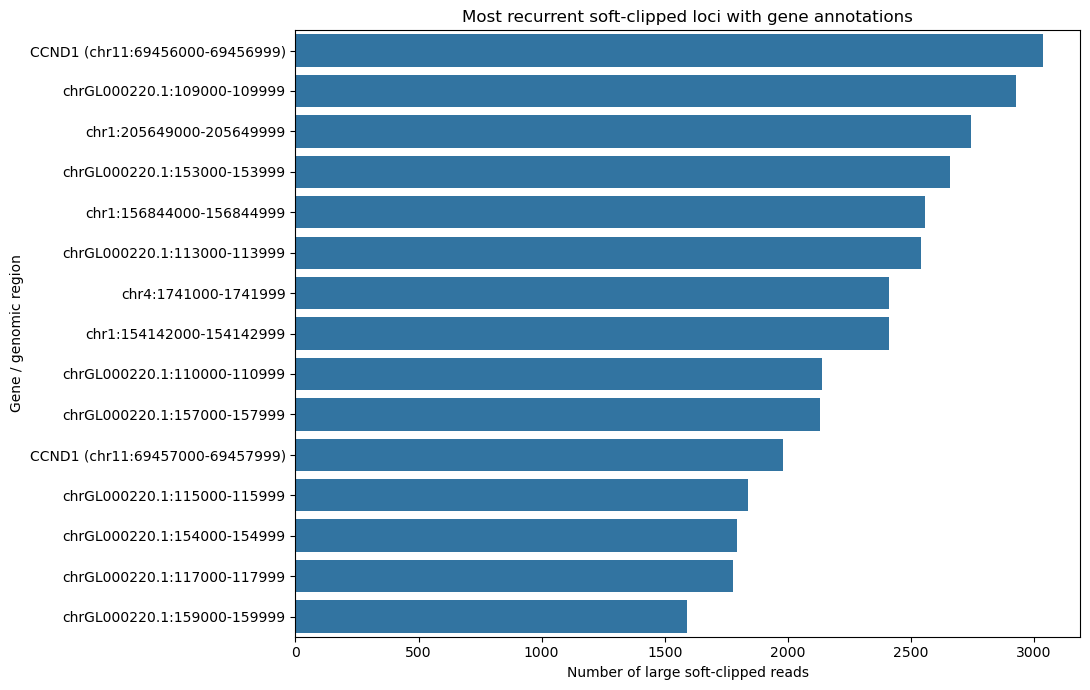

In [7]:
top_softclip_genes = (
    softclip_annot
    .groupby("gene_label")
    .agg(
        total_softclipped_reads=("n_softclipped_reads", "sum")
    )
    .reset_index()
    .sort_values("total_softclipped_reads", ascending=False)
    .head(15)
)

plt.figure(figsize=(11, 7))

sns.barplot(
    data=top_softclip_genes,
    x="total_softclipped_reads",
    y="gene_label"
)

plt.title("Most recurrent soft-clipped loci with gene annotations")
plt.xlabel("Number of large soft-clipped reads")
plt.ylabel("Gene / genomic region")

plt.tight_layout()

plt.savefig(
    fig_dir / "top_softclip_gene_annotated_loci.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

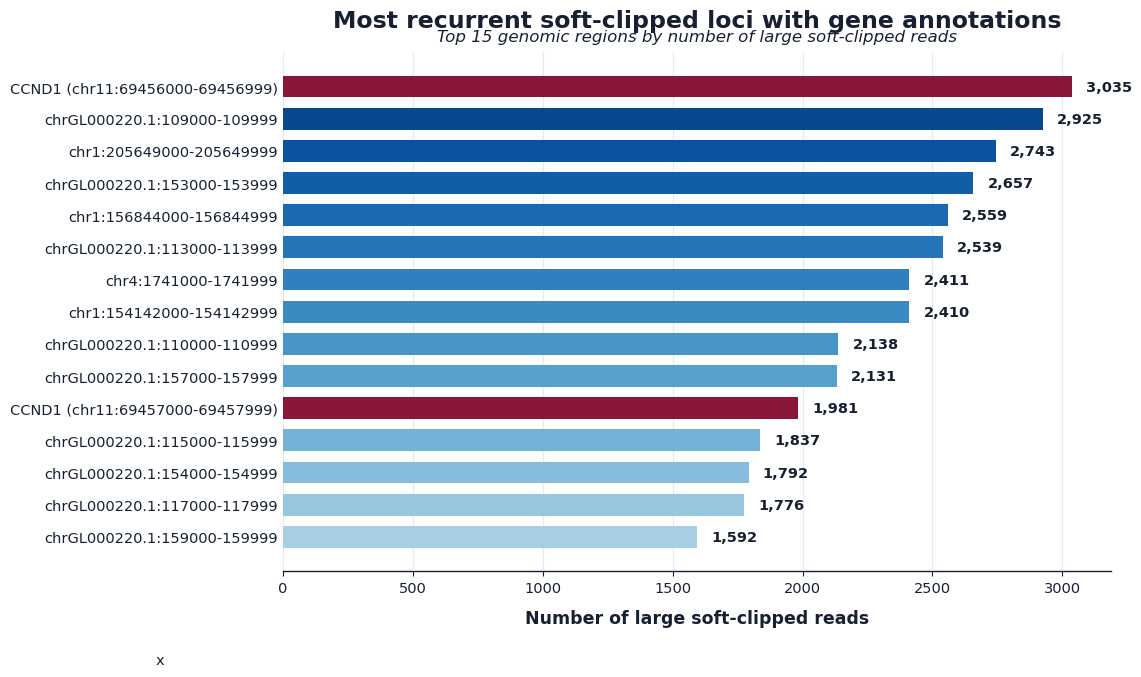

In [27]:
# Report-ready soft-clipped loci plot

top_softclip_genes = (
    softclip_annot
    .groupby("gene_label")
    .agg(
        total_softclipped_reads=("n_softclipped_reads", "sum")
    )
    .reset_index()
    .sort_values("total_softclipped_reads", ascending=False)
    .head(15)
)

# Sort ascending for horizontal bar plotting
plot_df = top_softclip_genes.sort_values(
    "total_softclipped_reads",
    ascending=True
).copy()

# Flag annotated loci for subtle emphasis
plot_df["is_annotated"] = plot_df["gene_label"].str.contains(
    r"^[A-Z0-9\-]+ \(",
    regex=True,
    na=False
)

fig, ax = plt.subplots(figsize=(11.5, 7.2))

navy = "#123A5A"
navy_light = "#8FB3D1"
red = "#8A1538"
text_color = "#172033"
grid_color = "#DDE6EE"

# gradient-like blues, with annotated CCND1 in muted red
colors = []
blue_vals = np.linspace(0.35, 0.95, len(plot_df))

for label, blue_alpha in zip(plot_df["gene_label"], blue_vals):
    if label.startswith("CCND1"):
        colors.append(red)
    else:
        colors.append(plt.cm.Blues(blue_alpha))

bars = ax.barh(
    plot_df["gene_label"],
    plot_df["total_softclipped_reads"],
    color=colors,
    height=0.68
)

# Add values to bar ends
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 55,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,}",
        va="center",
        ha="left",
        fontsize=10.5,
        fontweight="bold",
        color=text_color
    )

ax.set_title(
    "Most recurrent soft-clipped loci with gene annotations",
    fontsize=17,
    fontweight="bold",
    color=text_color,
    pad=18
)

ax.text(
    0.5,
    1.015,
    "Top 15 genomic regions by number of large soft-clipped reads",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=12,
    fontstyle="italic",
    color=text_color
)

ax.set_xlabel(
    "Number of large soft-clipped reads",
    fontsize=12.5,
    fontweight="bold",
    color=text_color,
    labelpad=10
)

ax.set_ylabel("")

ax.tick_params(axis="x", labelsize=10.5, colors=text_color)
ax.tick_params(axis="y", labelsize=10.5, colors=text_color, length=0)

ax.grid(axis="x", color=grid_color, linewidth=0.9, alpha=0.8)
ax.set_axisbelow(True)

# Clean frame
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

ax.spines["bottom"].set_color(text_color)
ax.spines["bottom"].set_linewidth(1)

# Add subtle note under plot
fig.text(
    0.14,
    0.035,
    "x",
    ha="left",
    va="center",
    fontsize=10.5,
    color=text_color
)

plt.tight_layout(rect=[0, 0.06, 1, 0.96])

plt.savefig(
    fig_dir / "top_softclip_gene_annotated_loci_report.png",
    dpi=450,
    bbox_inches="tight"
)

plt.show()

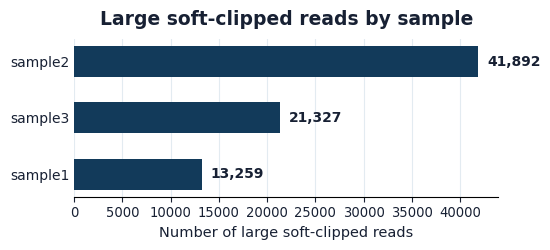

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

softclip_sample_counts = pd.DataFrame({
    "sample": ["sample1", "sample2", "sample3"],
    "softclipped_reads": [13259, 41892, 21327]
})

softclip_sample_counts = softclip_sample_counts.sort_values(
    "softclipped_reads",
    ascending=True
)

fig, ax = plt.subplots(figsize=(5.6, 2.6))

bar_color = "#123A5A"
text_color = "#172033"
grid_color = "#DDE6EE"

bars = ax.barh(
    softclip_sample_counts["sample"],
    softclip_sample_counts["softclipped_reads"],
    color=bar_color,
    height=0.55
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 900,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color=text_color
    )

ax.set_title(
    "Large soft-clipped reads by sample",
    fontsize=13.5,
    fontweight="bold",
    color=text_color,
    pad=10
)

ax.set_xlabel("Number of large soft-clipped reads", fontsize=10.5, color=text_color)
ax.set_ylabel("")

ax.grid(axis="x", color=grid_color, linewidth=0.8, alpha=0.8)
ax.set_axisbelow(True)

ax.tick_params(axis="x", labelsize=9.5, colors=text_color)
ax.tick_params(axis="y", labelsize=10, colors=text_color, length=0)

sns.despine(left=True, bottom=False)

plt.tight_layout()

plt.savefig(
    fig_dir / "softclipped_reads_by_sample_report.png",
    dpi=450,
    bbox_inches="tight"
)

plt.show()

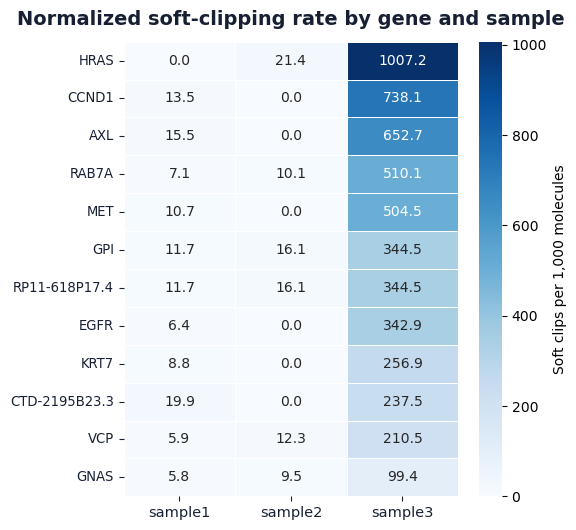

In [28]:
# Companion plot: normalized soft clipping by gene and sample

# assumes `merged` already exists with:
# sample, gene_name, n_softclipped_reads, total_dedup_molecules, softclips_per_1000_molecules

heat = merged.pivot_table(
    index="gene_name",
    columns="sample",
    values="softclips_per_1000_molecules",
    fill_value=0
)

# order by maximum normalized rate across samples
heat["max_rate"] = heat.max(axis=1)
heat = heat.sort_values("max_rate", ascending=False)

heat_plot = heat.drop(columns="max_rate").head(12)

# keep consistent sample order
sample_order = [s for s in ["sample1", "sample2", "sample3"] if s in heat_plot.columns]
heat_plot = heat_plot[sample_order]

fig, ax = plt.subplots(figsize=(5.8, 5.4))

sns.heatmap(
    heat_plot,
    cmap="Blues",
    linewidths=0.6,
    linecolor="white",
    annot=True,
    fmt=".1f",
    cbar_kws={"label": "Soft clips per 1,000 molecules"},
    ax=ax
)

ax.set_title(
    "Normalized soft-clipping rate by gene and sample",
    fontsize=14,
    fontweight="bold",
    color="#172033",
    pad=12
)

ax.set_xlabel("")
ax.set_ylabel("")

ax.tick_params(axis="x", labelsize=10.5, rotation=0, colors="#172033")
ax.tick_params(axis="y", labelsize=9.5, colors="#172033")

plt.tight_layout()

plt.savefig(
    fig_dir / "softclip_normalized_gene_sample_heatmap_report.png",
    dpi=450,
    bbox_inches="tight"
)

plt.show()

## Overall Conclusions

This analysis identified strong targeted enrichment across a limited set of recurrent genomic loci and genes, including **CCND1, FGFR1, AXL, MET, EGFR, RAF1, GNAS, and RAB7A**. Molecule-aware deduplication using `mb` barcodes demonstrated that raw sequencing depth substantially overestimated molecular abundance in some regions, particularly within sample3, which exhibited elevated amplification redundancy and reduced barcode complexity.

Variant analysis identified recurrent candidate variants within several enriched genes, most notably shared FGFR1 substitutions observed across all three samples. Additional sample-specific candidate variants were detected within multiple cancer-associated loci, although interpretation remains exploratory because the data derive from targeted RNA sequencing rather than matched DNA sequencing.

Soft-clipped read analysis further demonstrated that large clipping events were not randomly distributed across the genome. Instead, recurrent clustering occurred at highly enriched target loci, particularly around CCND1-associated regions, suggesting a combination of structured transcript complexity, alignment ambiguity, repetitive sequence mapping, and possible technical artifacts.

The data support a technically successful targeted sequencing assay with biologically structured enrichment patterns, while also highlighting substantial sample-specific technical differences that should be considered during downstream interpretation.

## Finally i want to execute these final steps.
- Extract soft-clipped sequences >15 bp.
- Write them to FASTA.
- Align clipped sequences back to hg19.
- Check whether clipped portions map to different chromosomes/genes than the original aligned read.

In [8]:
softclip_fasta = Path("../results/tables/large_softclipped_sequences.fasta")

with open(softclip_fasta, "w") as out:
    count = 0
    
    for bam_file in bam_files:
        sample = bam_file.stem
        bam = pysam.AlignmentFile(bam_file, "rb")
        
        for read in bam.fetch(until_eof=True):
            if read.is_unmapped or read.is_secondary:
                continue
            
            cigar = read.cigartuples
            seq = read.query_sequence
            
            if cigar is None or seq is None:
                continue
            
            left_clip = cigar[0][1] if cigar[0][0] == 4 else 0
            right_clip = cigar[-1][1] if cigar[-1][0] == 4 else 0
            
            if left_clip >= 15:
                clip_seq = seq[:left_clip]
                header = f">{sample}|{read.query_name}|left|{read.reference_name}:{read.reference_start}|clip={left_clip}"
                out.write(header + "\n")
                out.write(clip_seq + "\n")
                count += 1
            
            if right_clip >= 15:
                clip_seq = seq[-right_clip:]
                header = f">{sample}|{read.query_name}|right|{read.reference_name}:{read.reference_start}|clip={right_clip}"
                out.write(header + "\n")
                out.write(clip_seq + "\n")
                count += 1

count

[W::hts_idx_load3] The index file is older than the data file: ../data/bam/sample1.bam.bai
[W::hts_idx_load3] The index file is older than the data file: ../data/bam/sample2.bam.bai
[W::hts_idx_load3] The index file is older than the data file: ../data/bam/sample3.bam.bai


64539

In [9]:
subprocess.run(["which", "bwa"], capture_output=True, text=True).stdout

'/samurlab1/Joshua/joshMiniforge3/envs/nextflow/bin/bwa\n'

In [10]:
cmd = [
    "bwa", "mem",
    "-t", "4",
    str(ref_fasta),
    str(softclip_fasta)
]

with open(sam_out, "w") as out:
    result = subprocess.run(
        cmd,
        stdout=out,
        stderr=subprocess.PIPE,
        text=True
    )

print(result.stderr)
print("return code:", result.returncode)

NameError: name 'ref_fasta' is not defined

In [ ]:
remap_rows = []

with open(sam_out) as f:
    for line in f:
        if line.startswith("@"):
            continue

        fields = line.strip().split("\t")
        if len(fields) < 11:
            continue

        qname = fields[0]
        flag = int(fields[1])
        chrom = fields[2]
        pos = int(fields[3])
        mapq = int(fields[4])
        cigar = fields[5]
        seq = fields[9]

        if chrom == "*":
            continue

        remap_rows.append({
            "clip_id": qname,
            "remap_chrom": chrom,
            "remap_pos": pos,
            "remap_mapq": mapq,
            "remap_cigar": cigar,
            "clip_length": len(seq)
        })

remap_df = pd.DataFrame(remap_rows)

remap_df.to_csv(
    table_dir / "large_softclipped_sequences_remap_summary.csv",
    index=False
)

remap_df.head()

,clip_id,remap_chrom,remap_pos,remap_mapq,remap_cigar,clip_length
0,sample1|NB501618:163:HWFCNAFXX:1:11305:1497:11...,11,69457916,60,33M,33
1,sample1|NB501618:163:HWFCNAFXX:2:11309:2434:17...,11,69458599,60,6S42M,48
2,sample1|NB501618:163:HWFCNAFXX:4:21504:7102:15...,2,43712406,60,44M,44
3,sample1|NB501618:163:HWFCNAFXX:1:21302:12764:1...,19,59063642,60,41M,41
4,sample1|NB501618:163:HWFCNAFXX:3:21405:16588:1...,2,43712405,60,34M,34


#### Very interestingly we can see with remap_mapq and remap_cigar that these soft clips are confidently mapping confidently. Also remapping to chromosomes. 

In [ ]:
remap_summary = (
    remap_df
    .groupby(["remap_chrom"])
    .size()
    .reset_index(name="n_clipped_sequences")
    .sort_values("n_clipped_sequences", ascending=False)
)

remap_summary.head(20)

,remap_chrom,n_clipped_sequences
23,Un_gl000220,7333
1,10,2207
14,3,982
2,11,942
11,2,925
0,1,671
17,6,602
19,7,569
6,15,479
10,19,403


It appears that most of the clipped sequences are mapping to unplaced/repetitive contig. This strongly argues that many soft-clipped sequences are:
- repetitive 
- ambigiously mapping
- derived from homologous sequences distributed in the genome not uniquely represented in the genome. 

This is corroborates the findins with low MAPQ secondary alignments.

**It appears we are not seeing one dominant alternate chromosome indicating a clean fusion event from the soft clipped regions**.

### Remapping of Soft-Clipped Sequences Conclusion

To further investigate the origin of large soft-clipped segments, clipped sequences were extracted and independently remapped to the hg19 reference genome using BWA-MEM.

Many clipped sequences remapped confidently (`MAPQ=60`) to genomic loci, indicating that the clipped segments frequently contain biologically valid sequence rather than random low-quality bases. However, remapping patterns demonstrated strong enrichment toward repetitive or ambiguously mappable regions rather than clear recurrent fusion partners.

The strongest enrichment occurred within the `Un_gl000220` contig, an unplaced/repetitive reference sequence that accumulated thousands of remapped clipped fragments. Additional remapping occurred across multiple canonical chromosomes, including chromosomes 10, 3, 11, 2, 1, 6, and 7.

Collectively, these findings suggest that many large soft-clipped segments likely arise from:
- repetitive or homologous sequence content,
- ambiguous short-fragment alignment behavior,
- off-target enrichment,
- or structurally complex RNA fragments,

rather than a single dominant recurrent fusion event.

In [11]:
softclip_annot.groupby("gene_name")["n_softclipped_reads"] \
    .sum() \
    .sort_values(ascending=False) \
    .head(20)

gene_name
CCND1            5267
AXL              2968
RP11-618P17.4    1042
GPI              1042
MET              1038
KRT7             1035
GNAS              605
IDH2              594
BRAF              520
HRAS              467
RAB7A             454
VCP               370
CTD-2195B23.3     245
RAF1              186
EGFR              179
FGFR1             168
CHMP2A            144
MAP2K1            110
Name: n_softclipped_reads, dtype: int64

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

base = Path("/samurlab1/Joshua/smallRNA_analysis")
table_dir = base / "results/tables"
fig_dir = base / "results/figures"

gene_enrichment = pd.read_csv(table_dir / "gene_level_enrichment_summary.csv")

gene_enrichment.head()

,gene_name,gene_type,n_regions,n_samples,total_raw_reads,total_dedup_molecules,reads_per_molecule
0,CCND1,protein_coding,3,3,625935,90459,6.919544
1,AXL,protein_coding,6,3,417265,77404,5.390742
2,GNAS,protein_coding,2,3,299421,69477,4.309642
3,MET,protein_coding,5,3,290156,53704,5.402875
4,GPI,protein_coding,1,3,350786,50326,6.970274


In [14]:
softclip_summary = pd.read_csv(table_dir / "softclip_summary.csv")
softclip_loci = pd.read_csv(table_dir / "softclip_loci_summary.csv")

print("softclip_summary columns:")
print(softclip_summary.columns.tolist())

print("\nsoftclip_loci columns:")
print(softclip_loci.columns.tolist())

display(softclip_summary.head())
display(softclip_loci.head())

softclip_summary columns:
['sample', 'n_softclipped_reads', 'median_softclip', 'max_softclip', 'median_mapq']

softclip_loci columns:
['sample', 'chrom', 'bin', 'n_softclipped_reads', 'median_softclip', 'max_softclip', 'region']


,sample,n_softclipped_reads,median_softclip,max_softclip,median_mapq
0,sample1,13259,21.0,150,255.0
1,sample2,41892,22.0,151,255.0
2,sample3,21327,22.0,151,255.0


,sample,chrom,bin,n_softclipped_reads,median_softclip,max_softclip,region
0,sample1,GL000220.1,113000,681,21.0,38,chrGL000220.1:113000
1,sample1,GL000220.1,157000,670,21.0,38,chrGL000220.1:157000
2,sample1,11,69456000,544,21.0,51,chr11:69456000
3,sample1,11,69457000,460,21.0,51,chr11:69457000
4,sample1,GL000220.1,109000,453,21.0,48,chrGL000220.1:109000


In [16]:
# --------------------------------------------------
# Soft clipping normalized by molecular abundance
# --------------------------------------------------

softclip_df = (
    softclip_annot
    .groupby("gene_name")["n_softclipped_reads"]
    .sum()
    .reset_index()
)

softclip_df.columns = [
    "gene_name",
    "n_softclipped_reads"
]

compare_df = (
    gene_enrichment[
        ["gene_name", "total_dedup_molecules"]
    ]
    .merge(
        softclip_df,
        on="gene_name",
        how="inner"
    )
)

compare_df["softclips_per_1000_molecules"] = (
    compare_df["n_softclipped_reads"]
    / compare_df["total_dedup_molecules"]
) * 1000

compare_df = compare_df.sort_values(
    "softclips_per_1000_molecules",
    ascending=False
)

compare_df.head(20)

,gene_name,total_dedup_molecules,n_softclipped_reads,softclips_per_1000_molecules
0,CCND1,90459,5267,58.225273
13,HRAS,10914,467,42.789078
1,AXL,77404,2968,38.344272
10,BRAF,17127,520,30.361418
16,CTD-2195B23.3,9036,245,27.113767
6,KRT7,45779,1035,22.608620
4,GPI,50326,1042,20.705003
5,RP11-618P17.4,50326,1042,20.705003
7,IDH2,29072,594,20.432031
3,MET,53704,1038,19.328169


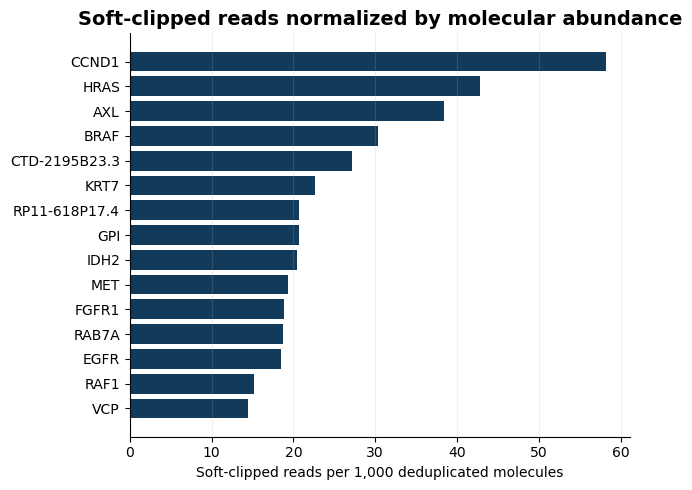

In [17]:
top = compare_df.head(15).copy()
top = top.sort_values(
    "softclips_per_1000_molecules",
    ascending=True
)

fig, ax = plt.subplots(figsize=(6.5, 5))

ax.barh(
    top["gene_name"],
    top["softclips_per_1000_molecules"],
    color="#123A5A"
)

ax.set_title(
    "Soft-clipped reads normalized by molecular abundance",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "Soft-clipped reads per 1,000 deduplicated molecules"
)

ax.set_ylabel("")

ax.grid(axis="x", alpha=0.2)
sns.despine()

plt.tight_layout()

plt.savefig(
    fig_dir / "softclip_normalized_by_molecules.png",
    dpi=450,
    bbox_inches="tight"
)

plt.show()

In [20]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

base = Path("/samurlab1/Joshua/smallRNA_analysis")
table_dir = base / "results/tables"
fig_dir = base / "results/figures"

sample_gene_enrichment = pd.read_csv(
    table_dir / "sample_gene_level_enrichment_summary.csv"
)

sample_gene_enrichment.head()

,sample,gene_name,gene_type,total_raw_reads,total_dedup_molecules,reads_per_molecule
0,sample1,CCND1,protein_coding,251290,84445,2.975783
1,sample1,AXL,protein_coding,187483,74067,2.531262
2,sample1,MET,protein_coding,114528,43685,2.621678
3,sample1,KRT7,protein_coding,115902,43223,2.681489
4,sample1,GPI,protein_coding,114357,30226,3.783398


In [21]:
softclip_gene_sample = (
    softclip_annot
    .groupby(["sample", "gene_name"])["n_softclipped_reads"]
    .sum()
    .reset_index()
)

dedup_gene_sample = (
    sample_gene_enrichment[
        ["sample", "gene_name", "total_dedup_molecules"]
    ]
)

merged = softclip_gene_sample.merge(
    dedup_gene_sample,
    on=["sample", "gene_name"],
    how="inner"
)

merged["softclips_per_1000_molecules"] = (
    merged["n_softclipped_reads"] /
    merged["total_dedup_molecules"]
) * 1000

merged.head()

,sample,gene_name,n_softclipped_reads,total_dedup_molecules,softclips_per_1000_molecules
0,sample1,AXL,1148,74067,15.499480
1,sample1,CCND1,1143,84445,13.535437
2,sample1,CTD-2195B23.3,174,8732,19.926706
3,sample1,EGFR,60,9305,6.448146
4,sample1,GNAS,129,22082,5.841862


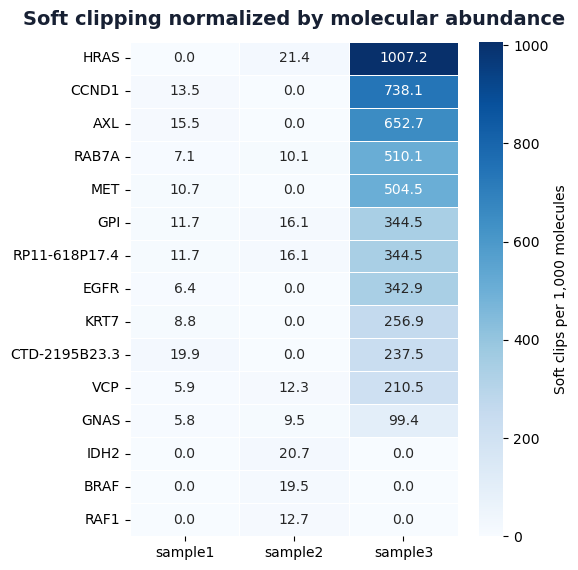

In [22]:
heat = merged.pivot_table(
    index="gene_name",
    columns="sample",
    values="softclips_per_1000_molecules",
    fill_value=0
)

heat["mean_rate"] = heat.mean(axis=1)
heat = heat.sort_values("mean_rate", ascending=False)
heat_plot = heat.drop(columns="mean_rate").head(15)

fig, ax = plt.subplots(figsize=(5.8, 5.8))

sns.heatmap(
    heat_plot,
    cmap="Blues",
    linewidths=0.6,
    linecolor="white",
    annot=True,
    fmt=".1f",
    cbar_kws={"label": "Soft clips per 1,000 molecules"},
    ax=ax
)

ax.set_title(
    "Soft clipping normalized by molecular abundance",
    fontsize=14,
    fontweight="bold",
    color="#172033",
    pad=12
)

ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()

plt.savefig(
    fig_dir / "softclip_rate_by_gene_sample_heatmap.png",
    dpi=450,
    bbox_inches="tight"
)

plt.show()

In [23]:
merged.sort_values(
    "softclips_per_1000_molecules",
    ascending=False
).head(30)

,sample,gene_name,n_softclipped_reads,total_dedup_molecules,softclips_per_1000_molecules
29,sample3,HRAS,279,277,1007.220217
24,sample3,CCND1,4121,5583,738.133620
23,sample3,AXL,1810,2773,652.722683
32,sample3,RAB7A,252,494,510.121457
31,sample3,MET,563,1116,504.480287
33,sample3,RP11-618P17.4,382,1109,344.454463
28,sample3,GPI,382,1109,344.454463
26,sample3,EGFR,119,347,342.939481
30,sample3,KRT7,653,2542,256.884343
25,sample3,CTD-2195B23.3,71,299,237.458194
